### 0. 데이터 로딩
- CSV 파일을 불러와서 분석에 사용할 Actor(cluster_sbert) 기준으로 데이터 준비

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# 처음 실행 시 주석 해제
!pip install kiwipiepy umap-learn scikit-learn gensim matplotlib pandas tqdm
!pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.1 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=c008ebc934497edb277aa45a1ba78ba8a8f636b1636b10c66c44d93d87009e3b
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [2]:
import pandas as pd
import ast

# CSV 파일 경로를 지정하세요
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX_prj/Sbert/merged_output/02_Shoes_Footwear_Care_merged.csv_document.csv"  # ← 실제 파일 경로로 변경

df = pd.read_csv(CSV_PATH)
df.head()

,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"['신발', '보관', '안녕', '미국', '주재원', '생활', '떠나', '가...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"['자유', '일상', '이야기', '신발', '보관', '접이식', '신발', '...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","['머리', '제목', '내용', '요약', '삭제', '말머리', '부아텅', '...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"['신발', '트렁크', '신발', '보관', '계시', '가지', '나오', '트...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"['신발', '보관', '어캐', '조던', '보관', '어캐', '관리']",신발 보관 어캐 조던 보관 어캐 관리,1


In [3]:
# tokens 컬럼이 문자열로 저장된 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

print("데이터 shape:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head()

데이터 shape: (68832, 5)
컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster_sbert']


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1


In [4]:
# Actor(cluster_sbert) 기준 군집 수 확인
print("cluster_sbert 군집별 문서 수:")
print(df['cluster_sbert'].value_counts().sort_index())

cluster_sbert 군집별 문서 수:
cluster_sbert
0     6971
1    40549
2     3149
3    18163
Name: count, dtype: int64


### 1. LDA를 위한 데이터 전처리
- 특정 Actor(cluster_sbert)를 선택하여 단어사전 생성 및 BOW 변환

In [5]:
# 분석할 Actor 번호 설정 (cluster_sbert 값 중 하나)
TARGET_ACTOR = 1  # ← 분석할 Actor 번호로 변경

df_actor = df[df['cluster_sbert'] == TARGET_ACTOR].copy()
print(f"Actor {TARGET_ACTOR} 문서 수:", df_actor.shape[0])
df_actor.head()

Actor 1 문서 수: 40549


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1


In [9]:
from gensim.corpora import Dictionary

# tokens 컬럼을 리스트로 변환
all_documents = list(df_actor['tokens'])

# 단어사전 구축
word_dict = Dictionary(all_documents)
print("단어사전 크기:", len(word_dict))
print("샘플 토큰:", list(word_dict.token2id.items())[:10])

단어사전 크기: 59567
샘플 토큰: [('가져가', 0), ('궁금하', 1), ('떠나', 2), ('물건', 3), ('미국', 4), ('보관', 5), ('생활', 6), ('선박', 7), ('신발', 8), ('안녕', 9)]


In [10]:
# 전체 문서에 BOW 변환
corpus = [word_dict.doc2bow(doc) for doc in all_documents]

# 샘플 확인
print("원문 토큰:", all_documents[0])
print("BOW 변환:", corpus[0])

원문 토큰: ['신발', '보관', '안녕', '미국', '주재원', '생활', '떠나', '가져가', '물건', '신발', '보관', '적히', '선박', '이사', '가져가', '현관', '신발', '보관', '궁금하']
BOW 변환: [(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 3), (6, 1), (7, 1), (8, 3), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1)]


### 2. 토픽 수 선정
- perplexity와 coherence를 비교하여 최적 토픽 수 결정

In [11]:
!pip install new_value_analysis -q

  0%|          | 0/8 [00:00<?, ?it/s]

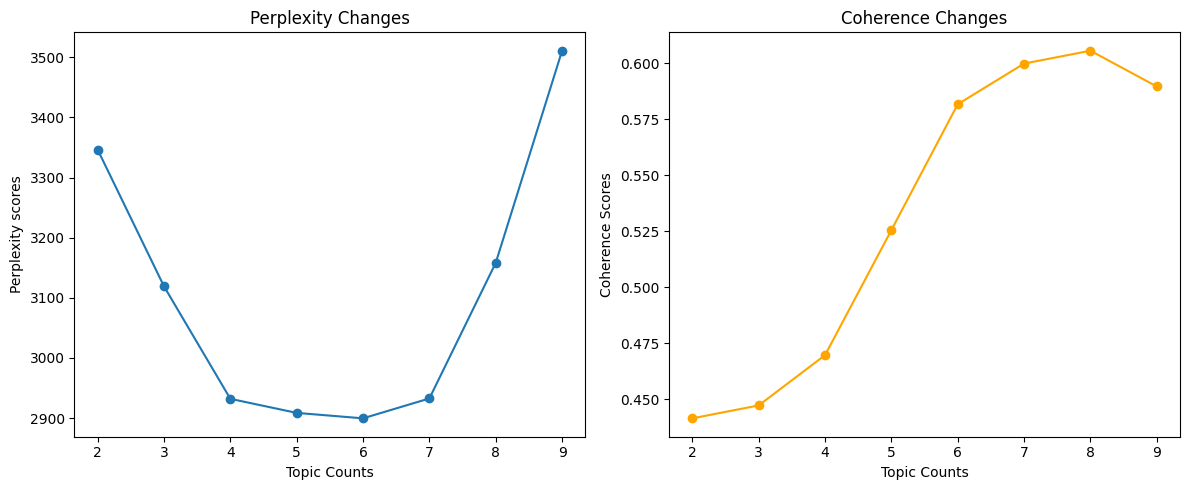

In [12]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

lda_perplexity_coherence_plot(
    corpus=corpus,
    word_dict=word_dict,
    all_documents=all_documents,
    topic_range=range(2, 10),   # 2~9개 토픽 수 비교
    passes=10,
    iterations=20,
    random_state=2026,
    fixed_topn=10,
    figsize=(12, 5)
)
# perplexity 낮을수록 좋고, coherence 높을수록 좋음
# 그래프를 보고 아래 TOPIC_NUM을 결정하세요

### 3. LDA 모델 학습 및 Action 번호 매칭

In [13]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import gensim

TOPIC_NUM = 6  # ← 위 그래프를 보고 결정한 토픽 수로 변경

ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    id2word=word_dict,
    num_topics=TOPIC_NUM,
    passes=10,
    iterations=20,
    random_state=2026
)

# 토픽별 주요 단어 확인
ldamodel.print_topics(num_words=10)

[(0,
  '0.088*"재생" + 0.048*"설정" + 0.043*"자막" + 0.032*"소거" + 0.032*"해상도" + 0.030*"사용" + 0.025*"기본" + 0.024*"속도" + 0.021*"도움말" + 0.017*"영상"'),
 (1,
  '0.010*"관리" + 0.008*"가능" + 0.007*"상품" + 0.006*"가전" + 0.006*"확인" + 0.006*"오브제" + 0.006*"상담" + 0.005*"진행" + 0.005*"가격" + 0.005*"계약"'),
 (2,
  '0.045*"신발" + 0.019*"구두" + 0.017*"구매" + 0.017*"질문" + 0.014*"게시판" + 0.014*"자유" + 0.012*"드리" + 0.009*"사진" + 0.009*"부츠" + 0.009*"정리"'),
 (3,
  '0.038*"케어" + 0.029*"신발" + 0.022*"관리" + 0.021*"제품" + 0.020*"구두" + 0.019*"사용" + 0.019*"가죽" + 0.018*"냄새" + 0.014*"크림" + 0.010*"제거"'),
 (4,
  '0.015*"신발" + 0.011*"통증" + 0.010*"수선" + 0.010*"밑창" + 0.009*"치료" + 0.008*"발바닥" + 0.008*"운동" + 0.008*"관리" + 0.008*"아프" + 0.006*"족저 근막염"'),
 (5,
  '0.007*"사람" + 0.006*"생각" + 0.005*"시간" + 0.004*"나오" + 0.004*"보이" + 0.004*"대하" + 0.004*"위하" + 0.003*"구두" + 0.003*"시작" + 0.003*"관리"')]

In [14]:
from new_value_analysis.action_finder import assign_action_number

action_number_assignment = assign_action_number(ldamodel, corpus=corpus)
print("Action 번호 할당 결과 샘플:", action_number_assignment[:10])

Action 번호 할당 결과 샘플: [2, 2, 2, 2, 2, 2, 2, 3, 2, 2]


In [15]:
print(f"데이터프레임 행 수: {len(df_actor)}")
print(f"새 데이터 리스트 수: {len(action_number_assignment)}")
print(f"차이: {len(df_actor) - len(action_number_assignment)}개 부족")

데이터프레임 행 수: 40549
새 데이터 리스트 수: 40549
차이: 0개 부족


In [16]:
# action 번호를 새로운 컬럼으로 추가
df_actor = df_actor.copy()
df_actor['action_cluster'] = action_number_assignment

print("Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())
df_actor.head()

Action별 문서 수:
action_cluster
0      611
1     2604
2    17284
3     8063
4     4542
5     7445
Name: count, dtype: int64


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1,2
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1,2
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1,2
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1,2
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1,2


### 4. pyLDAvis 시각화

In [17]:
!pip install pyldavis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 38.8 MB/s eta 0:00:00


In [18]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

prepared_data = gensimvis.prepare(ldamodel, corpus, word_dict)
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
# HTML로 저장
pyLDAvis.save_html(prepared_data, f"./ldavis_actor{TARGET_ACTOR}_action.html")
print(f"저장 완료: ldavis_actor{TARGET_ACTOR}_action.html")

저장 완료: ldavis_actor1_action.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 5. pyLDAvis 기준으로 Action 번호 재매핑
- LDA 모델의 토픽 인덱스와 pyLDAvis의 토픽 인덱스가 불일치할 수 있음
- 아래 매핑을 pyLDAvis 시각화 결과를 보고 직접 수정하세요

In [20]:
# LDA 토픽 번호 확인
print("LDA 토픽 번호 및 주요 단어:")
ldamodel.print_topics(num_words=10)

LDA 토픽 번호 및 주요 단어:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[(0,
  '0.088*"재생" + 0.048*"설정" + 0.043*"자막" + 0.032*"소거" + 0.032*"해상도" + 0.030*"사용" + 0.025*"기본" + 0.024*"속도" + 0.021*"도움말" + 0.017*"영상"'),
 (1,
  '0.010*"관리" + 0.008*"가능" + 0.007*"상품" + 0.006*"가전" + 0.006*"확인" + 0.006*"오브제" + 0.006*"상담" + 0.005*"진행" + 0.005*"가격" + 0.005*"계약"'),
 (2,
  '0.045*"신발" + 0.019*"구두" + 0.017*"구매" + 0.017*"질문" + 0.014*"게시판" + 0.014*"자유" + 0.012*"드리" + 0.009*"사진" + 0.009*"부츠" + 0.009*"정리"'),
 (3,
  '0.038*"케어" + 0.029*"신발" + 0.022*"관리" + 0.021*"제품" + 0.020*"구두" + 0.019*"사용" + 0.019*"가죽" + 0.018*"냄새" + 0.014*"크림" + 0.010*"제거"'),
 (4,
  '0.015*"신발" + 0.011*"통증" + 0.010*"수선" + 0.010*"밑창" + 0.009*"치료" + 0.008*"발바닥" + 0.008*"운동" + 0.008*"관리" + 0.008*"아프" + 0.006*"족저 근막염"'),
 (5,
  '0.007*"사람" + 0.006*"생각" + 0.005*"시간" + 0.004*"나오" + 0.004*"보이" + 0.004*"대하" + 0.004*"위하" + 0.003*"구두" + 0.003*"시작" + 0.003*"관리"')]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# ↓ pyLDAvis 시각화 결과를 보고 매핑 딕셔너리를 직접 수정하세요
# 예시: LDA 토픽 0 → pyLDAvis 토픽 2, LDA 토픽 1 → pyLDAvis 토픽 3, ...
topic_mapping = {
    0: 6,
    1: 4,
    2: 3,
    3: 2,
    4: 5,
    5: 1
}

df_actor['action_cluster'] = df_actor['action_cluster'].map(topic_mapping)

print("재매핑 후 Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

재매핑 후 Action별 문서 수:
action_cluster
1     7445
2     8063
3    17284
4     2604
5     4542
6      611
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
# 결과 저장 (pickle)
SAVE_PATH = f"./cluster_df_{TARGET_ACTOR}_action.pkl"
df_actor.to_pickle(SAVE_PATH)
print(f"저장 완료: {SAVE_PATH}")
df_actor.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

저장 완료: ./cluster_df_1_action.pkl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1,3
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1,3
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1,3
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1,3
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1,3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
(df_actor[df_actor["action_cluster"]==1]["text"]).to_csv("./tmp.csv", encoding="utf-8-sig")

PermissionError: [Errno 13] Permission denied: './tmp.csv'

In [ ]:
df_actor[df_actor["action_cluster"]==1]["text"]

In [ ]:
df_concat = pd.read_csv("./burnout_concat.csv",encoding ="utf-8")
df_concat

,source,body
0,twitter_3years_raw.csv,아 나 번아웃인가 왜 자꾸 눈물이 나
1,twitter_3years_raw.csv,그니까 같이 술을 마시는 횟수나 빈도보다도 \r\n자기가 자발적으로 찾아가는 사람이...
2,twitter_3years_raw.csv,ㅜ 하 진짜 이젠 머\r\n진짜 말도 안되는 별 거 아닌 거에도 짜증이 \r\n방금...
3,twitter_3years_raw.csv,너무 의욕읍거 무기력하거 일도 싫거 걍 녹아있고 싶기만해스 번아웃이 왓나싶긴한디 열...
4,twitter_3years_raw.csv,"캐설을 반영한다면\r\n마법소녀가 된 하네는 이런 전쟁.,, 전투...??를 영원히..."
...,...,...
9718,linkareer_번아웃.csv,번아웃 극복 방법 그동안 번아웃이 오면 번으로 극복하는 타입이었거든 좀 힘들다 싶으...
9719,linkareer_번아웃.csv,인턴이 번아웃 올 수 있는거임 은 좋아하는 일이어도 무조건 올 수 있더라 나는 야근...
9720,linkareer_번아웃.csv,번아웃 왔을 때 그냥 쉬면 괜찮아질까
9721,linkareer_번아웃.csv,헤어지고 번아웃오는거 제일 끔찍함 어떻게 아냐고 헤어지고 대외활동 여러개 붙어서 정...


In [ ]:
if df_actor[df_actor["action_cluster"]==1]["text"] in df_concat[df_concat["body"]]:
    print(df_concat[df_concat["body"]])

In [ ]:
# actor_texts를 하나의 정규표현식 패턴으로 만듭니다 (OR 연산자 | 활용)
import re
pattern = '|'.join(df_actor[df_actor["action_cluster"] == 1]["text"].apply(re.escape))

# body 컬럼에 해당 패턴이 포함된 행 찾기
matched_df = df_concat[df_concat["body"].str.contains(pattern, na=False)]

In [ ]:
matched_df.to_csv("./tmp.csv", encoding = "utf-8-sig")

In [ ]:
matched_df

,source,body
14,twitter_3years_raw.csv,서울콘 대만콘 다 다녀오면\r\n하얗게 불태워서 번아웃 올줄 알았는데\r\n무슨.....
61,twitter_3years_raw.csv,자유를 찾아 떠나기 전에는... 그 자유로 내가 뭘 하고 싶은 거신지... 쫌.. ...
172,twitter_3years_raw.csv,딩기 이발한 거 너무 예뻐서 나도 미용실 예약함ㅋ\r\n근데 늘 하던 디자이너 쌤 ...
191,twitter_3years_raw.csv,기관장미팅 납품 답사까지 정신없었다. 인천 끝까지 갔다 돌아와 남편이 말아준 밀크티...
270,twitter_3years_raw.csv,개인사고 일이고 좀 번아웃 온 거 같음\r\nMe-time이 필요하고 \r\n일단 ...
...,...,...
9521,blind_posts.csv,"⭐️⭐️⭐️⭐️- 커피 맛이 조금만 더 강하고 진했다면, 별 5개 받을만 함.- 또..."
9563,blind_posts.csv,[BOT] 운세[소띠 운세 🐄]새로운 음식으로 인하여 배앓이를 할 수 있다. 저녁 ...
9565,blind_posts.csv,밝고 명랑한 성격의 희정은 결혼을 한다.남편이 짠 신혼여행 코스는 스위스와 이탈리아...
9566,blind_posts.csv,오늘 별다른 일이 없어서 또 올려 봅니다 ^^“선배! 이렇게 따로 만난게 처음인거 ...


In [ ]:
friend_df = matched_df[matched_df["body"].str.contains("친구", na=False)]

In [ ]:
friend_df

,source,body
1451,naver_kin_burnout_clustered.xls,장기간의 학업 스트레스 누적 상태 . 슬럼프 상태 . 트라우마 상태의 지속으로 예상...
1742,naver_kin_burnout_clustered.xls,운동해서 땀 쫙뺀 후 목욕탕가서 목욕하고\n바나나우유 먹은 후 집가서 대자로 누워자...
3852,스레드_번아웃_concat.csv,번아웃을 이겨내는 소소한 습관들 10가지 1. 한가롭게 산책하며 자연안에서 힐링하기...
3870,스레드_번아웃_concat.csv,"[번아웃 4년, 회사 다니며 시도한 모든 것] 1. 아침에 모닝페이지 쓰기 2. 열..."
4285,스레드_번아웃_concat.csv,번아웃? 아침에 잠시 '나 번아웃 오는거 아니야?' 이런 생각이 들었다. 스스로를 ...
4376,스레드_번아웃_concat.csv,"번아웃이지만, 시간은 없고 해야 할 일은 쌓여만 갈때 이렇게 해보세요. 1. 새로운..."
4410,번아웃 크롤링.xlsx,"오늘의 건강 핵심 요약 데이터 번아웃은 단순한 피로를 넘어 신체적, 정신적 에너지가..."
4466,번아웃 크롤링.xlsx,"번아웃 아침에 눈 뜨는 게 너무 힘들다 , 출근만 생각하면 숨이 막힌다 , 아무것도..."
4472,번아웃 크롤링.xlsx,4년 차 미술치료사가 번아웃 끝에 직접 만든 감정일기 자기돌봄노트 소개해요 안녕하세...
4484,번아웃 크롤링.xlsx,이 포스팅은 원고료를 지원받아 작성되었습니다 회사 그만두고 싶다는 생각을 한 게 하...
